# <a id='toc1_'></a>[Bericht zur Datenqualität (epi2024_2) 📉](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Bericht zur Datenqualität (epi2024_2) 📉](#toc1_)    
  - [Änderungen seit der letzten Version](#toc1_1_)    
  - [Hinweise](#toc1_2_)    
  - [Datenstand 🕥](#toc1_3_)    
  - [Fallzahlen im Verlauf der Jahreslieferungen](#toc1_4_)    
    - [original geliefert](#toc1_4_1_)    
    - [nach Abschluss der Prüfungen im ZfKD](#toc1_4_2_)    
  - [Variablenverteilung](#toc1_5_)    
    - [Diagnosejahr](#toc1_5_1_)    
    - [Diagnosegruppen](#toc1_5_2_)    
    - [Diagnosesicherung](#toc1_5_3_)    
    - [DCO Diagramm](#toc1_5_4_)    
    - [DCO Tabelle](#toc1_5_5_)    
    - [Dignität](#toc1_5_6_)    
    - [Grading](#toc1_5_7_)    
    - [Altersgruppen](#toc1_5_8_)    
    - [UICC](#toc1_5_9_)    
    - [TNM-Auflage](#toc1_5_10_)    
    - [Tod](#toc1_5_11_)    
      - [Verteilung der Variable TOD im verarbeiteten Datensatz](#toc1_5_11_1_)    
      - [Verteilung der Variable TOD in den original gelieferten Daten](#toc1_5_11_2_)    
    - [Verteilung Todesursachen nach ICDT10](#toc1_5_12_)    
  - [Plausibilitätsprüfungen](#toc1_6_)    
    - [ ✅ 01-SH](#toc1_6_1_)    
    - [✅ 02-HH](#toc1_6_2_)    
    - [✅ 03-NI](#toc1_6_3_)    
    - [✅ 04-HB](#toc1_6_4_)    
    - [✅ 05-NW](#toc1_6_5_)    
    - [✅ 06-HE](#toc1_6_6_)    
    - [✅ 07-RP](#toc1_6_7_)    
    - [✅ 08-BW](#toc1_6_8_)    
    - [✅ 09-BY](#toc1_6_9_)    
    - [✅ 10-SL](#toc1_6_10_)    
    - [✅ 11-GKR (ehemals)](#toc1_6_11_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

<br>

## <a id='toc1_1_'></a>[Änderungen seit der letzten Version](#toc0_)
<!-- - bisher wurden folgende Angaben in einer umfangreichen Verarbeitung im workflow umkodiert: `ICDGM10`, `HISC`, `ICDO3`, `DIG`. Diese Umformung wurde deaktiviert, es finden nun nur noch punktuelle Korrekturen statt -->
- bei dem Kombinieren von klinischen Daten und dem GKR-Archiv wurden im letzten Datenstand filterbedingt Altfälle übernommen, die im workflow als DCO deklariert wurden und somit für `DJ` > 2020 gezählt sind. Diese Artefakte wurden entfernt
- seit `epi2023` wurde `DIG` 6 auf 3 gesetzt, diese Korrektur ist nun entfernt
- Neulieferung `06-HE` Daten

<br>

## <a id='toc1_2_'></a>[Hinweise](#toc0_)
- Bewertungen der Analysen sind mit 💡 markiert
- bei den Plausibilitätsprüfungen weist ein ✅ darauf hin, dass keine Mängel erkennbar sind

<br>

## <a id='toc1_3_'></a>[Datenstand 🕥](#toc0_)

In [1]:
import os
from pathlib import Path
import pandas as pd
import datetime as dt
from pandas_plots import tbl, pls, hlp
import duckdb as ddb

from connection_helper import sql
import numpy as np

hlp.show_package_version()

dir_db=Path("C://temp") if hlp.get_os(hlp.OperatingSystem.WINDOWS) else Path(os.path.expanduser("~/tmp"))

file_epi = dir_db/'2025-11-06_data_epi.duckdb'
file_meta = dir_db/'2025-11-06_meta_epi.duckdb'

if not file_epi.exists() or not file_meta.exists():
    raise Exception(f"files {file_epi} or {file_meta} not found")

URL_V2 = 'https://gitlab.opencode.de/robert-koch-institut/zentrum-fuer-krebsregisterdaten/cancerdata-references/-/raw/main/data/v2/'

os.environ['THEME']='light'

🐍 3.12.8 | 📦 pandas: 2.3.3 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.4.1 | 📦 pandas-plots: 0.20.7 | 📦 connection-helper: 0.13.1


In [2]:
sql.print_meta(file_epi)

sqlite db file:          2025-11-06_data_epi.duckdb
data tag:                nur 15-ST
sql table created:       2025-11-06 16:26:09
doi:                     -
document created:        2025-11-06 16:40:48


In [3]:
_=con = ddb.connect()
_=con.execute("PRAGMA disable_progress_bar;")
_=con.execute(f"ATTACH DATABASE '{file_epi}' AS epi (READ_ONLY);")
_=con.execute(f"ATTACH DATABASE '{file_meta}' AS meta (READ_ONLY); set schema 'epi';")

In [4]:
# todo add dim tables to epi duckdb

dim_dig = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/dig.csv", sep=";")
# dim_dsich_clin = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/diagnosesicherung_clin.csv", sep=";")
dim_dsich_epi = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/diagnosesicherung_epi.csv", sep=";")
# dim_grading_clin = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/grading_clin.csv", sep=";")
dim_grading_epi = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/grading_epi.csv", sep=";")
# dim_icd10 = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/icd10.csv", sep=";")
# dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")
# dim_landkreis = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/landkreis.csv", sep=";")
dim_lieferregister = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/lieferregister.csv", sep=";")
dim_icd10_3d = sql.load_file_to_duckdb(con, URL_V2 + "Aggregationen/icd10_3d.csv", sep=";")
# dim_op_intention = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/op_intention.csv", sep=";")
# dim_tnm_t = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/tnm_t.csv", sep=";")
# dim_tnm_uicc = sql.load_file_to_duckdb(con, URL_V2 + "Klassifikationen/tnm_uicc.csv", sep=";")

dim_tree = sql.load_file_to_duckdb(con, "../../src/quality-reports/data/dim_tree.csv", sep=";")

dim_lieferregister_= dim_lieferregister.to_df().set_index('code').replace({"11-BE":"11-GKR"})
dim_dsich_epi = dim_dsich_epi.to_df().assign(label=lambda x: x['code'].astype(str)+ ' - ' + x['name']).set_index('code')
dim_dig = dim_dig.to_df().assign(label=lambda x: x['code'].astype(str) + ' - ' + x['name']).set_index('code')
dim_grading_epi = dim_grading_epi.to_df().assign(label=lambda x: x['code'].astype(str) + ' - ' + x['name']).set_index('code')

In [5]:
Batches = con.sql("select * from meta.Batches;")
Checks = con.sql("select * from meta.Checks;")
ColumnCheck = con.sql("select * from meta.ColumnCheck;")
Frequencies = con.sql("select * from meta.Frequencies;")
# _meta_meta = con.sql("select * from meta._meta;")

df_checks = Checks.to_df().astype({"EKRNR": str})
df_freqs = (
    Frequencies.project(
        "*, concat(cast(BatchID as varchar),' | ', cast(cast(BatchZeit as date) as varchar)) as batch_label"
    )
    .to_df()
    .astype({"EKRNR": str})
)
df_freqs["EKRNR"] = df_freqs["EKRNR"].astype(int).replace(dim_lieferregister_["kkr"].to_dict())
df_checks["EKRNR"] = df_checks["EKRNR"].astype(int).replace(dim_lieferregister_["kkr"].to_dict())
df_batches= Batches.to_df()
df_columnchecks= ColumnCheck.to_df().set_index('ColumnCheckID')
df_checks = df_checks.join(df_columnchecks, on='ColumnCheckID')
df_checks["check_label"] = df_checks.apply(lambda x: f"{x['Alias']}[{x['ColumnCheckID']}]", axis=1)
df_checks= df_checks[["EKRNR","Anzahl","BatchID","DJahr","check_label","ColumnCheckID"]]

In [6]:
db_epi = con.sql("select * from Tumor4;").project("*, left(ICDGM10,3) as icd10_3d")

In [7]:
batch_max=df_checks['BatchID'].max()
batch_min=399
db_list_dy="(2023)"    # must be a str list, since "alt" is in dy col - or a ddb compatible str

In [8]:
print(f"\n{'latest batch:': <25}{batch_max}")
print(f"Berücksichtigt werden folgende Diagnosejahre 📆: {db_list_dy}")


latest batch:            419
Berücksichtigt werden folgende Diagnosejahre 📆: (2023)


<div style="page-break-after: always;"></div>

## <a id='toc1_4_'></a>[Fallzahlen im Verlauf der Jahreslieferungen](#toc0_)
- kein Filter
- es werden Datenstände (_batch_) aus mehreren Lieferjahren dargestellt , welche über eine laufende Nummer sowie das Datum der Ausführung vergleichbar sind
- in Abgrenzung zu den klinischen Daten ist jede einzelne EKR Lieferung für das gesamte Lieferjahr gültig

<br>

### <a id='toc1_4_1_'></a>[original geliefert](#toc0_)
- aufgeführt sind die Fallzahlen aus den überlieferten Dateien **vor** den ZfKD Anpassungen
- `batch_label` markiert den jeweils letzten offiziellen Datenstand des Lieferjahres, sowie den aktuellen Datenstand

In [9]:
_df=df_freqs[(df_freqs.Stufe==2) & (df_freqs.Alias=="SEX") & (df_freqs.BatchID.isin([batch_max,418,416,399,360,331]))]
_df=_df.pivot_table(index="batch_label", columns="EKRNR", values="Anzahl", aggfunc="sum")
tbl.show_num_df(_df, total_axis="y", data_bar_axis="x")

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,Total
batch_label,,,,,,,,,,,,
331 | 2021-08-27,587_631,360_229,1_463_161,125_482,2_724_356,734_674,704_114,679_700,1_428_235,347_949,3_191_041,12_346_572
360 | 2023-01-03,624_239,371_807,1_545_623,132_265,2_906_452,782_871,632_930,766_070,1_535_587,360_943,3_605_815,13_264_602
399 | 2024-12-02,734_305,423_109,1_816_413,151_753,3_991_177,918_534,823_343,1_048_203,1_811_372,400_646,3_792_956,15_911_811
416 | 2025-04-01,780_626,445_714,1_911_528,157_932,4_186_192,958_031,863_935,1_152_455,1_916_313,412_559,3_974_287,16_759_572
418 | 2025-06-20,780_626,445_714,1_911_528,157_932,4_186_192,973_597,863_935,1_152_455,1_916_313,412_559,3_950_260,16_751_111
419 | 2025-11-06,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,155_458,155_458


<br>

### <a id='toc1_4_2_'></a>[nach Abschluss der Prüfungen im ZfKD](#toc0_)
- Filter: jeweils das **letzte DJ** der einzelnen Jahreslieferung
- aufgeführt sind die Fallzahlen aus den überlieferten Dateien **nach** den ZfKD Anpassungen

In [10]:
_df=df_freqs[
    (df_freqs.Stufe==5) & 
    (df_freqs.Alias=="SEX") & 
    (df_freqs.BatchID.isin([batch_max,418,416,399,360,331]))
    & (df_freqs.DJahr!="alt")
    ]
_df=_df.pivot_table(index="batch_label", columns="EKRNR", values="Anzahl", aggfunc="sum")
tbl.show_num_df(_df, total_axis="y", data_bar_axis="x")

EKRNR,01-SH,02-HH,03-NI,04-HB,05-NW,06-HE,07-RP,08-BW,09-BY,10-SL,11-GKR,Total
batch_label,,,,,,,,,,,,
331 | 2021-08-27,30_360,15_919,78_800,6_469,184_032,36_672,27_758,77_246,79_741,11_137,119_770,667_904
360 | 2023-01-03,32_401,17_099,81_092,6_548,176_210,38_279,25_194,77_968,85_001,11_391,164_812,715_995
399 | 2024-12-02,33_243,18_238,85_016,6_086,193_412,38_294,28_779,78_883,80_929,11_665,162_633,737_178
416 | 2025-04-01,34_512,18_011,86_331,5_068,202_655,30_291,30_000,81_600,84_717,11_076,157_970,742_231
418 | 2025-06-20,34_512,18_011,86_331,5_068,202_655,44_073,30_000,81_320,84_717,11_076,155_450,753_213
419 | 2025-11-06,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,23_799,23_799


In [11]:
# # * internal check
# _df=(df_checks[(df_checks.ColumnCheckID==48) & (df_checks.BatchID >= batch_min) & (df_checks.BatchID != 415)].sort_values('BatchID'))
# _df=_df.pivot_table(index="BatchID", columns="EKRNR", values="Anzahl", aggfunc="sum").fillna(0)
# tbl.show_num_df(_df, total_axis="y", data_bar_axis="x")

<div style="page-break-after: always;"></div>

## <a id='toc1_5_'></a>[Variablenverteilung](#toc0_)
<!-- - **Filter:**
  - **🚨 sofern nicht anders angegeben ist der Zeitraum beschränkt auf das höchste Diagnosejahr (für `epi2024`: 2023) 🚨**
  - Diagnosen: ausgeschlossen sind `C44` und alle `D` -->
- ab hier wird nur die aktuelle Datenlieferung dargestellt
- als ungültig markierte Fälle (_A-Prüfungen_) sind in allen Fallzahlen ausgeschlossen
- in den barplots sind die relativen Häufigkeiten von Variablen im Datensatz der Register aufgetragen
- zusätzlich ist die Angabe für alle kkr enthalten (`Total`)
- näherungsweise sind GKZ-Bundesländer verwendet anstatt Lieferregister, um 11-16 aufspannen zu können

In [12]:
def show_freqs_batch(df: pd.DataFrame, batch: int, alias: str, current_only: bool = False) -> None:
    if current_only:
        df=df[df['DJahr'] != 'alt']
    df=df.loc[
        (df['BatchID'] == batch)
        & (df['Alias'] == alias)
        & (df['Stufe'] == 5)
        ,['EKRNR','Wert','Anzahl']]
    return df
    # pls.plot_stacked_bars(df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=f'{alias} {batch_max}', show_total=True)

# print(f"Mögliche Variablen für Auswertung: \n{df_freqs.Alias.unique()}")
_aliases=['DJ','DSICH','DCO','DIG','GRAD','ALTGRP', 'UICC','TNMAUFL', 'TOD','GKZAUFL']

# ! switch from kkr -> bl
# print(f"{np.array(db_epi.columns)}")
def show_freqs(alias: str, db_list_dy: str = db_list_dy, incl_c44_and_d = False)-> None:
    df = db_epi
    if not incl_c44_and_d:
        df = (df
                .filter(f"""--sql
                    left(ICDGM10,3) != 'C44' and left(ICDGM10,1)='C'
                """)
        )
    df = (df
            .filter(f"DJ in {db_list_dy}")
            .filter("GKZbl::int <=16")
            .filter("is_deleted = 0")
            .aggregate(f"GKZbl, {alias}, count(*) as cnt")
            .join(dim_lieferregister, "GKZbl = code", "left")
            .project("* exclude(code)")
            .to_df()
    )

    return df

caption_str=lambda alias, batch_max: f"{alias}"

<br>

### <a id='toc1_5_1_'></a>[Diagnosejahr](#toc0_)
- **Filter: DJ > 2018, C44 und D-Diagnosen sind ausgeschlossen**

> 💡 `ZfKD`: _"Insbesondere aus `06-HE`, `15-ST` und `16-TH` fehlt für 2023 noch ein spürbarer Anteil an Fällen"_

In [13]:
_df=show_freqs(alias="DJ", db_list_dy="(2019,2020,2021,2022,2023,2024,2025)", incl_c44_and_d=False).pivot_table(index="DJ", columns="kkr", values="cnt", aggfunc="sum")
tbl.show_num_df(_df, data_bar_axis="x", total_axis="y")

kkr,15-ST,Total
DJ,,
2019,16_216,16_216
2020,15_737,15_737
2021,15_188,15_188
2022,15_287,15_287
2023,15_550,15_550


In [14]:
# _alias='DJ'
# _df=show_freqs_batch(df_freqs, batch_max, _alias)
# _df = _df[_df["Wert"]>'2018'].pivot_table(index="Wert", columns="EKRNR", values="Anzahl")
# tbl.show_num_df(_df, data_bar_axis="x", total_axis="y")

### <a id='toc1_5_2_'></a>[Diagnosegruppen](#toc0_)
- **Filter: DJ = 2023, C44 und D-Diagnosen sind eingeschlossen**

> 💡 `ZfKD`: _"Die Anteile für D-Diagnosen sind in etwa vergleichbar, die für C44 unterscheiden sich recht deutlich"_

In [15]:
_alias = "icd10_3d"
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=True)
    .merge(dim_icd10_3d.to_df().set_index('code'), left_on=_alias, right_index=True, how="left")
    [["kkr", "code_kid", "cnt"]]
    .rename(columns={"kkr": "bl", "code_kid": "icd10_grp"})
)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=1000,
)

<br>

### <a id='toc1_5_3_'></a>[Diagnosesicherung](#toc0_)
- **Filter: DJ = 2023, C44 und D-Diagnosen sind ausgeschlossen**

> 💡 `ZfKD`: _"auffällig ist der hohe Anteil an fehlenden Diagnosesicherungen in `08-BW`"_
> 
> 💡 `ZfKD`: _"ebenfalls auffällig: Anzahl dokumentierter Obduktionen in `02-HH`. Da gleichzeitig auch DCO Fälle markiert sind ist ein Skriptfehler rund um die DCO Kodierung 0 vs 3 unwahrscheinlich"_

In [16]:
_alias = "DSICH"
_df = (
    show_freqs(alias=_alias)
    .merge(dim_dsich_epi, left_on=_alias, right_index=True, how="left")[
        ["kkr", "label", "cnt"]
    ]
    .rename(columns={"kkr": "bl", "label": _alias})
)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=800,
)

<br>

### <a id='toc1_5_4_'></a>[DCO Diagramm](#toc0_)
- **Filter: DJ = 2020-2023, C44 und D-Diagnosen sind ausgeschlossen, GKZbl 01-16**
- die epi Variable `DCO` wird wie folgt gebildet:
  - 1 wenn Diagnosesicherung = 3
  - sonst 2 (auch für Diagnosesicherung missing) 

> 💡 `ZfKD`: _"für DJ 2023 sind keine DCO Fälle markiert aus den KKR 13-16"_

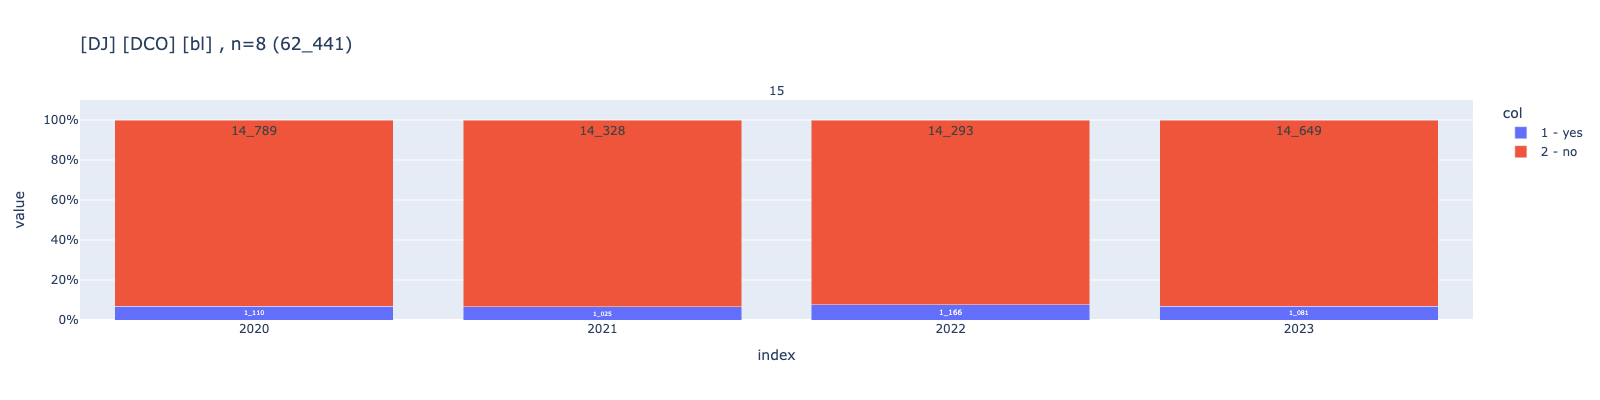

In [17]:
_df= (db_epi
    .filter("DJ between 2020 and 2023 and left(ICDGM10,3) <> 'C44' and left(ICDGM10,1) = 'C'")
    .filter("GKZbl::int <=16")
    .project("""--sql
        GKZbl, DCO, DJ
    """)
    #.filter("DSICH is null")
    .aggregate("DJ::text as DJ, DCO, GKZbl as bl, count(*) as cnt")
    .to_df()
)
_df["DCO"] = _df["DCO"].replace({1:"1 - yes", 2:"2 - no"})
# _df
_=pls.plot_facet_stacked_bars(
    _df,
    subplot_size=400,
    relative=True,
    annotations=True,
    # renderer=None,
)

### <a id='toc1_5_5_'></a>[DCO Tabelle](#toc0_)
- **Filter: DJ = 2010-2023, GKZbl 01-16**
- Metrik: Anteil DCO an Gesamtfallzahl in %
<!-- > 💡 für 09-BY sind in dieser Lieferung erheblich weniger DCO Fälle festzustellen -->

In [18]:
db_dco = con.sql("""--sql
    with t_all as (
        select  GKZbl as bl
                ,(DCO=1)::int as is_dco
                ,case when IARC like '%A_Mehrfach%' then 1 else 0 end as is_multiple
                ,DJ as dy
        from    db_epi
    )
    --select * from t_all
    --where bl::int between 1 and 16
    select  bl, dy
            ,sum(is_dco) as sum_dco, sum(is_multiple) as sum_multiple
            ,sum(is_dco) / count(*) * 100 as pct_dco
            ,sum(is_multiple) / count(*) * 100 as pct_multiple
            ,count(*) as cnt
    from    t_all
    where bl::int between 1 and 16
    and dy::int between 2010 and 2023
    group by all
    """)
# tbl.descr_db(db_dco, "dco data")

In [19]:
tbl.pivot_df(db_dco.project("bl, dy, pct_dco").to_df(),swap=True, precision=2, pct_axis="", total_axis="")

bl,15
dy,
2018,5.90
2019,4.42
2020,4.42
2021,4.07
2022,4.40
2023,3.95


<br>

### <a id='toc1_5_6_'></a>[Dignität](#toc0_)
- **Filter: DJ = 2020-2023, C44 und D-Diagnosen sind eingeschlossen**


In [20]:
# _alias = "DIG"
# _df = (
#     show_freqs(alias=_alias, incl_c44_and_d=False, db_list_dy="(2023)")
#     .merge(dim_dig, left_on=_alias, right_index=True, how="left")[
#         ["kkr", "label", "cnt"]
#     ]
#     .rename(columns={"kkr": "bl", "label": _alias})
# )
# _=pls.plot_stacked_bars(
#     _df,
#     orientation="h",
#     normalize=False,
#     relative=True,
#     dropna=False,
#     sort_values_index=False,
#     # caption=caption_str(_alias, batch_max),
#     show_total=True,
#     height=600,
# )

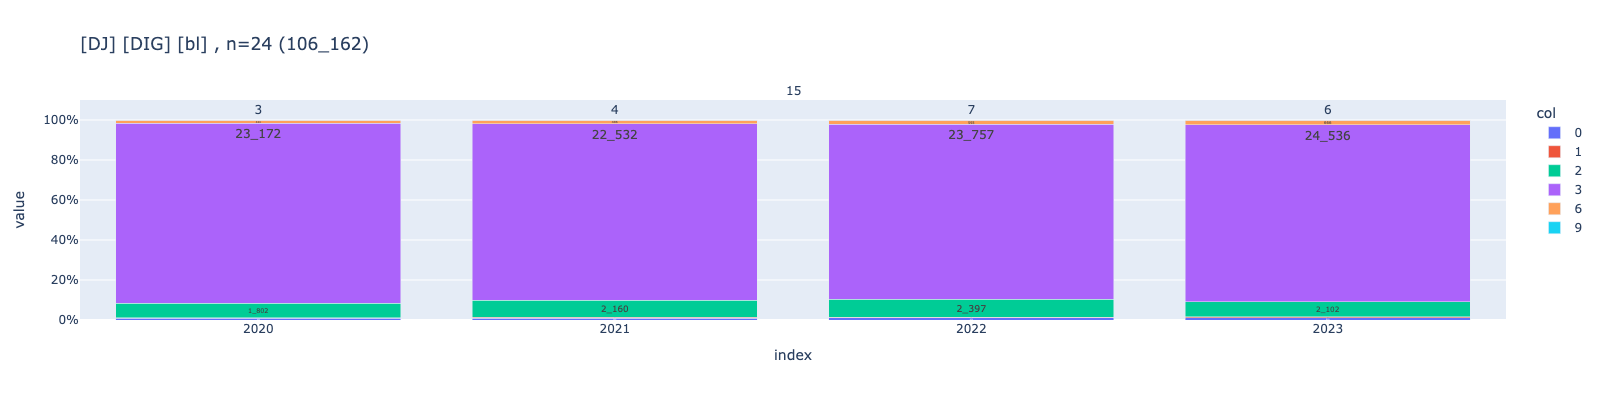

In [21]:
_df = (
    db_epi.filter("DJ between 2020 and 2023 and GKZbl::int <= 16")
    .aggregate("DJ::text as DJ, DIG::text as DIG, GKZbl as bl, count(*) as cnt")
    .to_df()
)
# _df
_ = pls.plot_facet_stacked_bars(
    _df,
    subplot_size=400,
    relative=True,
    annotations=True,
)

<br>

### <a id='toc1_5_7_'></a>[Grading](#toc0_)
- **Filter: DJ = 2023, C44 und D-Diagnosen sind ausgeschlossen**

In [22]:
_alias='GRAD'
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=False)
    .merge(dim_grading_epi, left_on=_alias, right_index=True, how="left")[
        ["kkr", "label", "cnt"]
    ]
    .rename(columns={"kkr": "bl", "label": _alias})
)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=800,
)

<br>

### <a id='toc1_5_8_'></a>[Altersgruppen](#toc0_)

- **Filter: DJ = 2023, C44 und D-Diagnosen sind ausgeschlossen**


In [23]:
# _alias='ALTGRP'
# _df=show_freqs_batch(df_freqs[df_freqs["DJahr"].isin(list_dy)], batch_max, _alias)
# _=pls.plot_stacked_bars(_df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=caption_str(_alias, batch_max), show_total=True, height=600)

In [24]:
_alias='ALTGRP'
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=False)
    .rename(columns={"kkr": "bl"})
    [["bl", "ALTGRP", "cnt"]]
)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=800,
)

<br>

### <a id='toc1_5_9_'></a>[UICC](#toc0_)
- **Filter: DJ = 2023, C44 und D-Diagnosen sind ausgeschlossen**
- die Variable `UICC` wird vom ZfKD gebildet

In [25]:
# _alias='UICC'
# _df=show_freqs_batch(df_freqs[df_freqs["DJahr"].isin(list_dy)], batch_max, _alias)
# _=pls.plot_stacked_bars(_df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=caption_str(_alias, batch_max), show_total=True, height=600 )

In [26]:
_alias='UICC'
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=False)
    .rename(columns={"kkr": "bl"})
    [["bl", "UICC", "cnt"]]
)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=800,
)

<br>

### <a id='toc1_5_10_'></a>[TNM-Auflage](#toc0_)
- **Filter: DJ = 2023, C44 und D-Diagnosen sind ausgeschlossen**
- nicht übermittelte Auflagen werden im ZfKD geschätzt und imputiert anhand des DJ, daher keine missings

> 💡 `ZfKD`: _"Auflage 7 nur noch von 03-NI in nennenswertem Umfang übermittelt"_

In [27]:
# _alias='TNMAUFL'
# _df=show_freqs_batch(df_freqs[df_freqs["DJahr"].isin(list_dy)], batch_max, _alias)
# _=pls.plot_stacked_bars(_df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=caption_str(_alias, batch_max), show_total=True,height=600 )

In [28]:
_alias='TNMAUFL'
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=False)
    .rename(columns={"kkr": "bl"})
    [["bl", "TNMAUFL", "cnt"]]
)
_df["TNMAUFL"] = _df["TNMAUFL"].astype(str).str.zfill(2)
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=800,
)

# todo regel ergänzen für imputation

<br>

### <a id='toc1_5_11_'></a>[Tod](#toc0_)

#### <a id='toc1_5_11_1_'></a>[Verteilung der Variable TOD im verarbeiteten Datensatz](#toc0_)
- **Filter: DJ = 2023, C44 und D-Diagnosen sind ausgeschlossen**


In [29]:
# _alias='TOD'
# _df=show_freqs_batch(df_freqs[df_freqs["DJahr"].isin(list_dy)], batch_max, _alias)
# _df["Wert"] = _df["Wert"].replace({"1":"1 - Ja", "2":"2 - Nein"})
# _=pls.plot_stacked_bars(_df, orientation='h', normalize=False, relative=True, dropna=False, sort_values=False, caption=caption_str(_alias, batch_max), show_total=True, height=600)

In [30]:
_alias='TOD'
_df = (
    show_freqs(alias=_alias, incl_c44_and_d=False)
    .rename(columns={"kkr": "bl"})
    [["bl", "TOD", "cnt"]]
)
_df["TOD"] = _df["TOD"].replace({1:"1 - Ja", 2:"2 - Nein"})
_=pls.plot_stacked_bars(
    _df,
    orientation="h",
    normalize=False,
    relative=True,
    dropna=False,
    sort_values_index=False,
    show_total=True,
    height=800,
    )
# todo kurz erklären

<br>

#### <a id='toc1_5_11_2_'></a>[Verteilung der Variable TOD in den original gelieferten Daten](#toc0_)
- Grundgesamtheit: alle Daten mit DJ > 1970
- neben `J` und `N` sind diverse Formen von Leerkodierungen unterschieden (`NULL`, `''`, `' '` etc.)
- die Daten den Registern ohne missings enthalten eine eindeutige Information zu `TOD`
- bei allen sonstigen EKR wird angenommen: Todesangabe leer -> lebend
> 💡 `08-NW`: _"Die Umkodierung von missing auf `N` können wir gerne vornehmen"_

In [31]:
_df = (con.from_df(df_freqs)
    .filter(f"Alias = 'TOD' and Stufe = 2 and BatchID = {batch_max}")
    .project("""--sql
            Alias,EKRNR, Anzahl,
            case when trim(ifnull(Wert,'')) = '' then '<NA>' else Wert end as Wert
            """)
    .to_df()
    .pivot_table(
        index="Wert",
        columns="EKRNR",
        values="Anzahl",
        aggfunc="sum",
        fill_value=0,
        dropna=False,
    )
)
tbl.show_num_df(_df, total_axis="xy", data_bar_axis="x")

EKRNR,11-GKR,Total
Wert,,
,96_245,96_245
J,59_213,59_213
Total,155_458,155_458


### <a id='toc1_5_12_'></a>[Verteilung Todesursachen nach ICDT10](#toc0_)
- gezählt sind **Personen**
- **Filter: `SJ` >= 2010**
- `icdt10_1d` gibt die erste Stelle der Todesursache an
- ⚠️ für `01-SH` und `02-HH` sind die DJ nicht in korrekter Reihenfolge

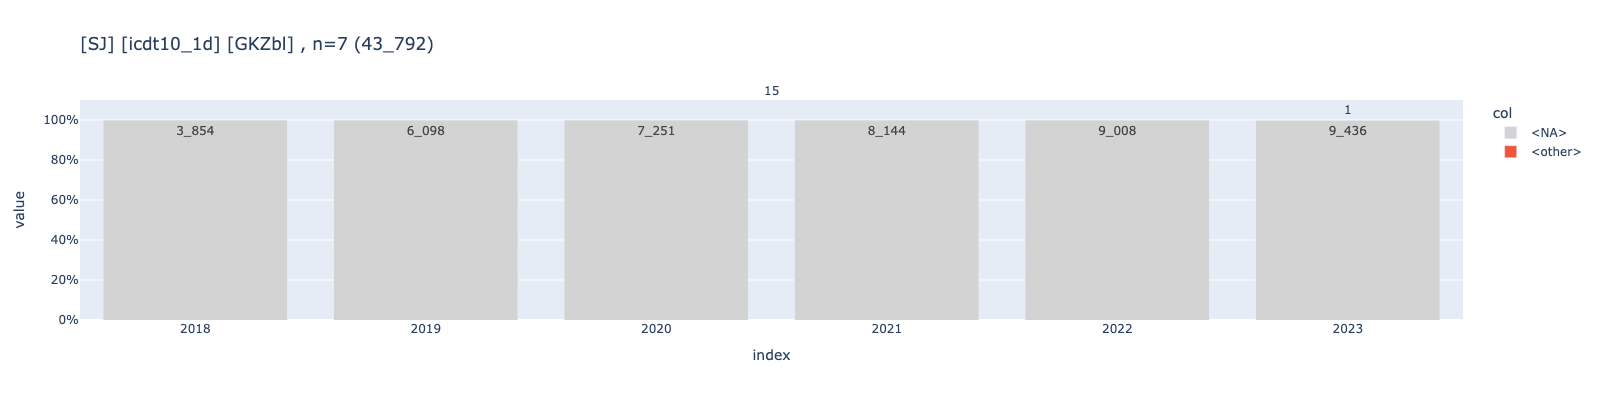

In [32]:
df_tu2 = (db_epi
    .project("""--sql
            year(SDIMP)::text as SJ, 
            ICDT10, 
            GKZbl, 
            case when ifnull(ICDT10,'') = '' then null when upper(left(ICDT10,1)) = 'C' then 'C' else '<other>' end as icdt10_1d, 
            GLOBALPATID
            """)
    .filter("SJ::int >= 2010 and GKZbl::int <= 16")
    .aggregate("""--sql
            SJ, icdt10_1d, GKZbl
            ,count(distinct GLOBALPATID) as cnt_pat
            --,count(*) as cnt
    """)
    .to_df()
)

_ = pls.plot_facet_stacked_bars(
    df_tu2,
    # df_tu[["SJ","icdt10_1d","GKZbl"]],
    # df_tu[["DJ","ICDT10","EKRNR"]],
    # top_n_color=5,
    subplot_size=400,
    # sort_values_facet=True,
    relative=True,
    annotations=True,
)

<div style="page-break-after: always;"></div>

## <a id='toc1_6_'></a>[Plausibilitätsprüfungen](#toc0_)
- **Filter**
  - **es ist jeweils nur das aktuellste DJ berücksichtigt (2023 vs 2022 aus letzter Lieferung)**
- Die Tabellen sind zur besseren Lesbarkeit nun aufgeteilt nach den Plausibilitätsprüfungen ([pdf](https://www.krebsregisterverbund.de/attachments/download/8743/Plausibilit%C3%A4tspr%C3%BCfungen_details.pdf))
  - `A`: Fälle ausgeschlossen
  - `B`: Fälle markiert
  - `C`: Fälle korrigiert 
- Spalten
  - `cnt_epi2022`: Absolute Fallzahl der checks für das in diesem Datensatz höchste DJ (2021) [batch385]
  - `cnt_now`: Absolute Fallzahl der checks für das im aktuellen Datensatz höchsten DJ (2022)
  - `pct_epi2022`: Anteil Fallzahl der checks an allen Fällen für das in diesem Datensatz höchste DJ (2021) [batch385]
  - `pct_now`: Anteil Fallzahl der checks an allen Fällen für das im aktuellen Datensatz höchste DJ (2022)
  - _(Absolute Fallzahlen = nach Abzug der A-Prüfungen)_

In [33]:
# def show_checks(df: pd.DataFrame, batches: list, reg: str, relative: bool = False) -> None:
#     df=df.loc[
#         (df['BatchID'].isin(batches))
#         & (df['EKRNR'] == reg)
#         & (df['DJahr'] != 'alt')
#         ,['BatchID','check_label','Anzahl']]
#     # display(df)
#     df1 = (df[df["check_label"].str.endswith("[48]")])[["BatchID", "Anzahl"]]
#     df2 = df.merge(df1, on="BatchID")
#     df2["pct"] = round(df2["Anzahl_x"] / df2["Anzahl_y"] * 100,1)
#     if relative:
#         df2 = df2[["BatchID", "check_label", "pct"]]
#     else:
#         df2 = df2[["BatchID", "check_label", "Anzahl_x"]]
#     # display(df2)
#     display(tbl.pivot_df(df2, swap=True, data_bar_axis='x', total_axis="", pct_axis=""))

# batches=[376,385,batch_max]
# ekr_epi2023=sorted(df_checks[df_checks.BatchID>385].EKRNR.unique())

In [34]:
def show_checks2(df_in: pd.DataFrame, reg: str) -> None:
    def get_ser(
        df_in: pd.DataFrame, batch_id: int, reg: str, suffix: str
    ) -> pd.DataFrame:
        df = df_in.copy()
        total = df.loc[
            (df["BatchID"] == batch_id)
            & (df["EKRNR"] == reg)
            & (df["DJahr"] != "alt")
            & (df["check_label"] == "I_Fallzahl[48]"),
            ["BatchID", "check_label", "Anzahl"],
        ].iloc[0, -1]

        df_out = df.loc[
            (df["BatchID"] == batch_id) & (df["EKRNR"] == reg) & (df["DJahr"] != "alt"),
            ["BatchID", "check_label", "Anzahl"],
        ]

        df_out["pct"] = df_out["Anzahl"] / total * 100
        return (
            df_out.rename(columns={"Anzahl": "cnt_" + suffix, "pct": "pct_" + suffix})
            .iloc[:, 1:]
            .reset_index(drop=True)
        )

    df0 = get_ser(df_checks, 399, reg, "epi2023")
    df1 = get_ser(df_checks, batch_max, reg, "now")

    df = (
        pd.merge(df0, df1, on="check_label", how="outer")
        .set_index("check_label")
        .iloc[:, [0, 2, 1, 3]]
    )
    df_ab = df[df.index.str.startswith(("A_", "B_","I_"))]
    df_a = df[df.index.str.startswith(("A_","I_"))]
    df_b = df[df.index.str.startswith(("B_","I_"))]
    df_c = df[df.index.str.startswith(("C_","I_"))]
    display(tbl.show_num_df(df_a, total_axis="", data_bar_axis="x", col1_width=300))
    display(tbl.show_num_df(df_b, total_axis="", data_bar_axis="x", col1_width=300))
    display(tbl.show_num_df(df_c, total_axis="", data_bar_axis="x", col1_width=300))
    return

<br>

### <a id='toc1_6_1_'></a>[ ✅ 01-SH](#toc0_)

In [35]:
# show_checks(df_checks, batches=batches, reg='01-SH', relative=False)
show_checks2(df_checks, "01-SH")

IndexError: index 0 is out of bounds for axis 0 with size 0

<div style="page-break-after: always;"></div>

### <a id='toc1_6_2_'></a>[✅ 02-HH](#toc0_)

In [ ]:
# show_checks(df_checks, batches=batches, reg='02-HH', relative=True)
show_checks2(df_checks, "02-HH")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_3_'></a>[✅ 03-NI](#toc0_)

In [ ]:
# show_checks(df_checks, batches=batches, reg='03-NI', relative=False)
show_checks2(df_checks, "03-NI")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_4_'></a>[✅ 04-HB](#toc0_)

In [ ]:
# show_checks(df_checks, batches=batches, reg='04-HB', relative=False)
# show_checks(df_checks, batches=batches, reg='04-HB', relative=True)
show_checks2(df_checks, "04-HB")

In [ ]:
# print(f"{np.array(db_epi.columns)}")
# db_epi.filter("EKRNR = '04' and DJ = '2022'").value_counts("IARC")
# db_epi.filter("EKRNR = '04' and DJ = '2022' and IARC like '%1_korrigiert_aufgrund_Sterbeangaben%'").project("TOD, SDIMP")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_5_'></a>[✅ 05-NW](#toc0_)

In [ ]:
# show_checks(df_checks, batches=batches, reg='05-NW', relative=True)
show_checks2(df_checks, "05-NW")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_6_'></a>[✅ 06-HE](#toc0_)

In [ ]:
# show_checks(df_checks, batches=batches, reg='06', relative=True)
show_checks2(df_checks, "06-HE")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_7_'></a>[✅ 07-RP](#toc0_)

In [ ]:
# show_checks(df_checks, batches=batches, reg='07-RP', relative=True)
show_checks2(df_checks, "07-RP")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_8_'></a>[✅ 08-BW](#toc0_)

In [ ]:
# show_checks(df_checks, batches=batches, reg='08-BW', relative=True)
show_checks2(df_checks, "08-BW")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_9_'></a>[✅ 09-BY](#toc0_)

In [ ]:
# show_checks(df_checks, batches=batches, reg='09-BY', relative=True)
show_checks2(df_checks, "09-BY")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_10_'></a>[✅ 10-SL](#toc0_)

In [ ]:
# show_checks(df_checks, batches=batches, reg='10-SL', relative=True)
show_checks2(df_checks, "10-SL")

<div style="page-break-after: always;"></div>

### <a id='toc1_6_11_'></a>[✅ 11-GKR (ehemals)](#toc0_)

In [36]:
# show_checks(df_checks, batches=batches, reg='11-GKR', relative=True)
show_checks2(df_checks, "11-GKR")

,cnt_epi2023,cnt_now,pct_epi2023,pct_now
check_label,,,,
A_EKRNR_GKZ_unplausibel[83],79,nan,0,nan
A_ICD10_keineAuswertung[54],394,717,0,3
A_Mehrfachmeldung[37],10_738,3_219,7,14
A_SEX_fehlerhaft[1],9,2,0,0
I_Fallzahl[48],162_633,23_799,100,100


,cnt_epi2023,cnt_now,pct_epi2023,pct_now
check_label,,,,
B_DALT_HISC_ICD10_unplausibel[67],41,5,0,0
B_DALT_unplausibel[77],3,2,0,0
B_DCO_DDIMP_inkonsistent[39],13,nan,0,nan
B_DIG_HISC_unplausibel[70],1_021,193,1,1
B_DIG_ICDO3_unplausibel[69],3,nan,0,nan
B_DSICH_HISC_unplausibel[72],2_017,169,1,1
B_Entscheidung_Mehrfachtumor_unplausibel[82],18,2,0,0
B_GRAD_HISC_unplausibel[85],183,31,0,0
B_HISC_ICDO3_unplausibel[55],2_894,364,2,2


,cnt_epi2023,cnt_now,pct_epi2023,pct_now
check_label,,,,
C_DIG_korrigiert[64],2_416,16,1,0
C_DJ_korrigiert_aufgrund_DSICH[43],908,1,1,0
C_HISC_korrigiert[56],329,169,0,1
C_ICD10DREI_korrigiert[80],1_123,149,1,1
C_ICDO3_korrigiert[52],5,80,0,0
C_LOKS_korrigiert[84],946,128,1,1
C_SJ>MaxJahr[14],8_548,2_717,5,11
C_TNMx_korrigiert[44],1,1,0,0
C_TOD=1_korrigiert_aufgrund_Sterbeangaben[74],224,2,0,0


In [ ]:
if False:
    df_pivot = (db_epi
        .filter("GKZbl::int <= 16")
        # .project("")
        .project("""
                GKZbl, DJ::text as DJ, is_deleted::bool as is_deleted, IARC, DCO
                ,case when IARC like '%A_Mehr%' then true else false end as is_multiple
                ,case when IARC like '%A_ICD10_keineAuswertung%' then true else false end as has_wrong_icd10
            """)
        .aggregate("GKZbl, DJ, is_deleted, IARC, DCO, count(*) as cnt, is_multiple, has_wrong_icd10")
        .to_df()
    )
    spec = "config/epi_pygwalker_spec.json"
    hlp.add_measures_to_pyg_config(spec, nodes=[("cnt_tum","sum(cnt)")])

    import pygwalker as pyg

    pyg.walk(df_pivot, appearance=os.getenv("THEME"), kernel_computation=True, spec=spec)

In [ ]:
# _df = db_epi.filter("IARC like '%A_ICD10_keineAuswertung%' and EKRNR = '11' and DJ > '2016'").aggregate("cast(DJ as varchar) as DJ, count(DJ) as cnt").order("DJ").to_df()
# print("Auswertung Fallzahlen für den Test A_ICD10_keineAuswertung[54] für DJ vor und nach 2020: vor 2020 gibt es keine Auffälligkeiten")
# _=pls.plot_bars(_df, height=500, width=600, caption="[54] DJ um 2020")

In [37]:
con.close()